In [1]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# Models (7+)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv


In [2]:
train=pd.read_csv("/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv");
test=pd.read_csv("/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv")
sample_submission=pd.read_csv("/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv")

In [3]:
print(train.dtypes)

ID                            int64
mushroom_id                   int64
cap-shape                    object
cap-surface                  object
cap-color                    object
bruises                      object
number_of_bruises             int64
odor                         object
gill-attachment              object
gill-spacing                 object
gill-size                    object
gill-color                   object
stalk-shape                  object
stalk-root                   object
stalk-surface-above-ring     object
stalk-surface-below-ring     object
stalk-color-above-ring       object
stalk-color-below-ring       object
veil-type                    object
veil-color                   object
ring-number                 float64
ring-type                    object
spore-print-color            object
population                   object
habitat                      object
class                        object
dtype: object


In [4]:
train.describe()

,ID,mushroom_id,number_of_bruises,ring-number
count,7000.000000,7000.000000,7000.000000,6964.000000
mean,3500.500000,3850.617714,5.459571,1.080988
std,2020.870275,2208.389867,7.723528,0.272836
min,1.000000,0.000000,0.000000,1.000000
25%,1750.750000,2000.750000,0.000000,1.000000
50%,3500.500000,3755.500000,0.000000,1.000000
75%,5250.250000,5602.250000,11.000000,1.000000
max,7000.000000,8118.000000,24.000000,2.000000


In [5]:
train.isnull().sum()

ID                             0
mushroom_id                    0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
number_of_bruises              0
odor                        3236
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                   192
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                   36
ring-type                     36
spore-print-color              0
population                     0
habitat                        0
class                          0
dtype: int64

In [6]:
def impute_dataset(train, test):

    for col in train.columns:
        if col == "class":
            continue

        if train[col].dtype != "object":
            value = train[col].mean()
        else:
            value = train[col].mode()[0]

        train[col].fillna(value,inplace=True)
        test[col].fillna(value,inplace=True)

    return train, test

In [7]:
train_imputed, test_imputed= impute_dataset(train, test)

print("\nRemaining nulls in train:")
print(train_imputed.isnull().sum())

print("\nRemaining nulls in test:")
print(test_imputed.isnull().sum())


Remaining nulls in train:
ID                          0
mushroom_id                 0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
number_of_bruises           0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
class                       0
dtype: int64

Remaining nulls in test:
ID                          0
mushroom_id                 0
cap-shape                   0
cap-surface                 0
cap-color                   0
brui

/tmp/ipykernel_17/637436631.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(value,inplace=True)
/tmp/ipykernel_17/637436631.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.metho

In [8]:
print("Duplicates:", train.duplicated().sum())
train = train.drop_duplicates()

Duplicates: 0


In [9]:
num_cols = train_imputed.select_dtypes(include=["int64","float64"]).columns

Q1 = train[num_cols].quantile(0.25)
Q3 = train[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((train_imputed[num_cols] < (Q1 - 1.5 * IQR)) | 
            (train_imputed[num_cols] > (Q3 + 1.5 * IQR))).sum()

print("Outliers per column:\n", outliers)

Outliers per column:
 ID                     0
mushroom_id            0
number_of_bruises      0
ring-number          600
dtype: int64


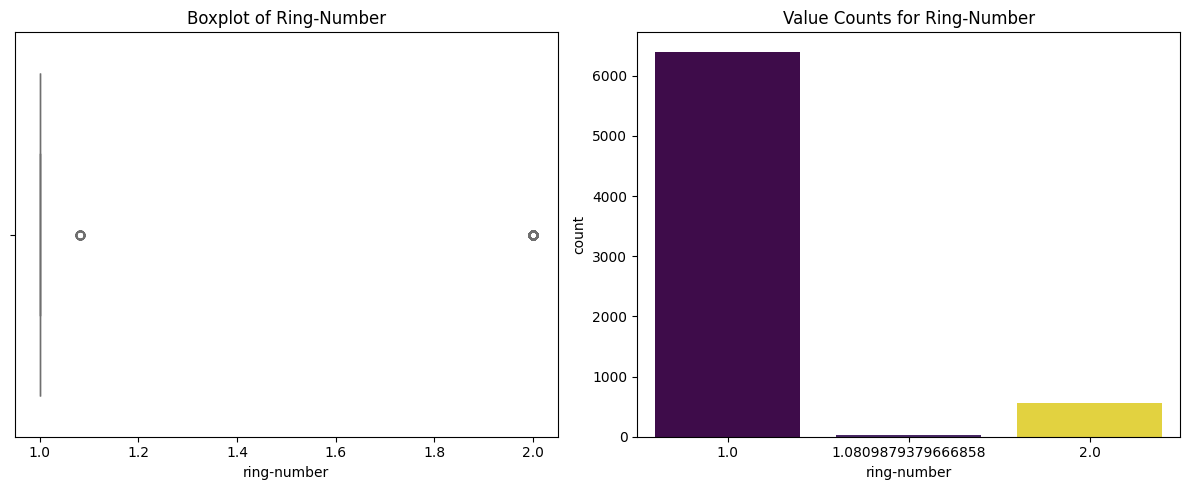

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 1x2 grid for plots
plt.figure(figsize=(12, 5))

# 1. Boxplot (Standard Outlier View)
plt.subplot(1, 2, 1)
sns.boxplot(x=train_imputed['ring-number'], color='skyblue')
plt.title('Boxplot of Ring-Number')

# 2. Countplot (Actual Value Distribution)
plt.subplot(1, 2, 2)
sns.countplot(x=train_imputed['ring-number'], hue=train_imputed['ring-number'], palette='viridis', legend=False)

plt.title('Value Counts for Ring-Number')

plt.tight_layout()
plt.show()


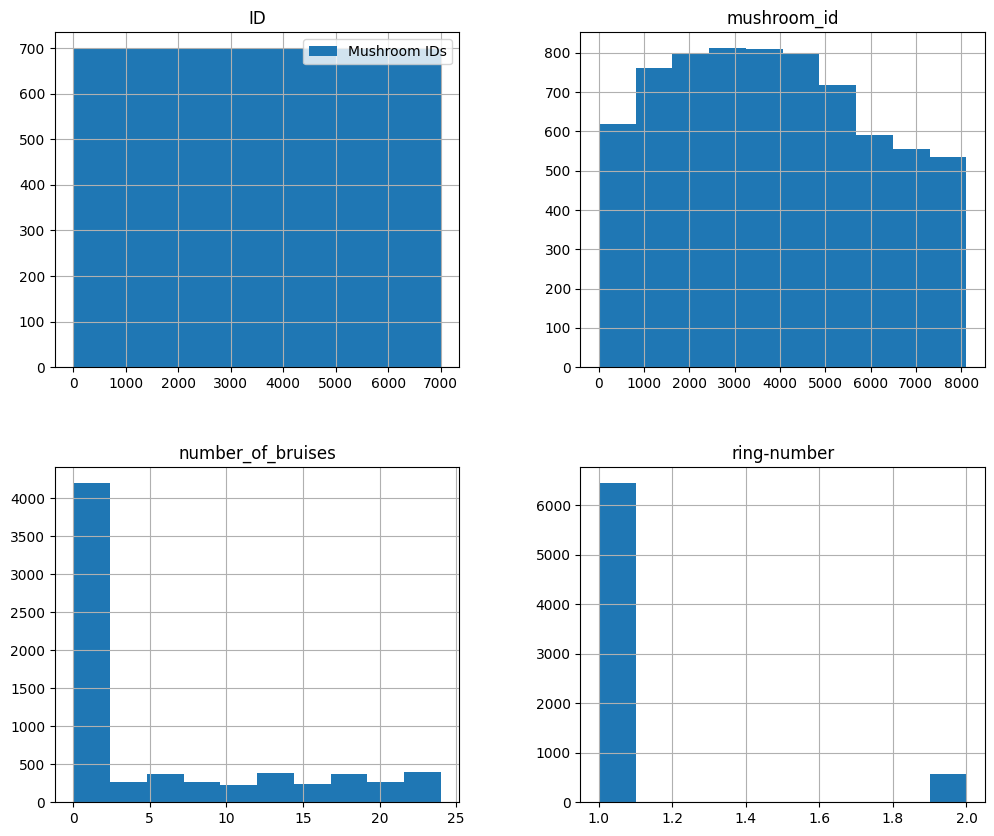

In [11]:
import matplotlib.pyplot as plt

# Generate the axes
axes = train_imputed.hist(figsize=(12,10))

# Access the top-left axis (for 'ID' column) and set a label
# The axes are a 2D array, axes[0, 0] is the top-left plot
ax = axes[0, 0]
ax.legend(["Mushroom IDs"])

plt.show()

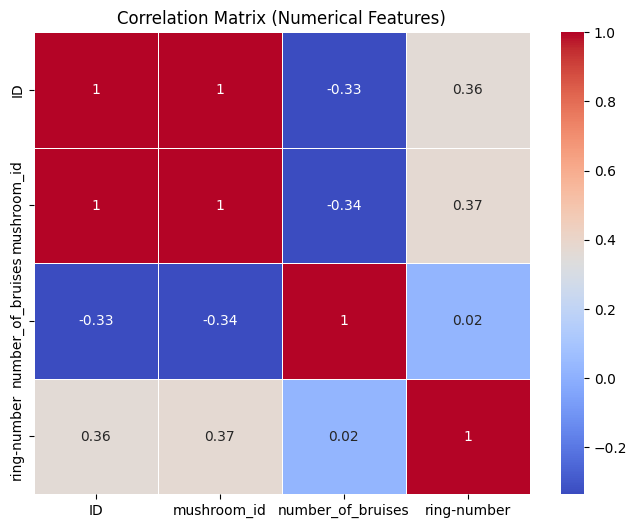

In [12]:
import seaborn as sns

numeric_df = train_imputed.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,        
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix (Numerical Features)")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
X=train_imputed.drop(['class', 'ID', 'mushroom_id'], axis=1)
y=train_imputed['class']

In [14]:
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns
categorical_cols = X.select_dtypes(include=["object","category"]).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

Numeric columns: ['number_of_bruises', 'ring-number']
Categorical columns: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

In [16]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

y_encoded

array([1, 0, 1, ..., 1, 1, 1])

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   
)

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

validation_scores = {}

for name, model in models.items():

    model.fit(x_train, y_train)

    preds_val = model.predict(x_val)

    acc = accuracy_score(y_val, preds_val)

    validation_scores[name] = acc

    print(f"{name} validation accuracy: {acc:.4f}")

Logistic Regression validation accuracy: 1.0000
Decision Tree validation accuracy: 1.0000
Random Forest validation accuracy: 1.0000
SVM validation accuracy: 1.0000
KNN validation accuracy: 1.0000
Gradient Boosting validation accuracy: 1.0000
AdaBoost validation accuracy: 0.9943


In [19]:
rf_params = {
    'n_estimators': [100, 300],
    'max_depth': [10,20]
}

rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=3)
rf_grid.fit(x_train, y_train)



GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [10, 20], 'n_estimators': [100, 300]})

In [20]:
print("Best Randomforest params:", rf_grid.best_params_)
print("Best RandomForest CV score:", rf_grid.best_score_)

Best Randomforest params: {'max_depth': 10, 'n_estimators': 100}
Best RandomForest CV score: 1.0


In [21]:
svm_params = {
    'C': [1, 10],
    'kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(SVC(), svm_params, cv=3)
svm_grid.fit(x_train, y_train)



GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [1, 10], 'kernel': ['linear', 'rbf']})

In [22]:
print("Best SVC_linear params:", svm_grid.best_params_)
print("Best SVC_linear CV score:", svm_grid.best_score_)

Best SVC_linear params: {'C': 1, 'kernel': 'linear'}
Best SVC_linear CV score: 1.0


In [23]:
knn_params = {
    'n_neighbors': [3,5,7]
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3)
knn_grid.fit(x_train, y_train)



GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7]})

In [24]:
print("Best KNNClassifier params:", knn_grid.best_params_)
print("Best KNNClassifier CV score:", knn_grid.best_score_)

Best KNNClassifier params: {'n_neighbors': 3}
Best KNNClassifier CV score: 1.0


In [25]:
results = []

for name, acc in validation_scores.items():

    results.append({
        "model": name,
        "validation_accuracy": acc,
        "tuned_cv_accuracy": None,
        "best_params": None
    })

results.append({
    "model": "randomforest_tuned",
    "validation_accuracy": accuracy_score(
        y_val,
        rf_grid.best_estimator_.predict(x_val)
    ),
    "tuned_cv_accuracy": rf_grid.best_score_,
    "best_params": rf_grid.best_params_
})
results.append({
    "model": "SVC_linear_kernel_tuned",
    "validation_accuracy": accuracy_score(
        y_val,
        svm_grid.best_estimator_.predict(x_val)
    ),
    "tuned_cv_accuracy": svm_grid.best_score_,
    "best_params": svm_grid.best_params_
})

results.append({
    "model": "KNN_classifier_tuned",
    "validation_accuracy": accuracy_score(
        y_val,
    knn_grid.best_estimator_.predict(x_val)
    ),
    "tuned_cv_accuracy": knn_grid.best_score_,
    "best_params": knn_grid.best_params_
})
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="validation_accuracy",
    ascending=False
)

results_df = results_df.reset_index(drop=True)

print(results_df)

                     model  validation_accuracy  tuned_cv_accuracy  \
0      Logistic Regression             1.000000                NaN   
1            Decision Tree             1.000000                NaN   
2            Random Forest             1.000000                NaN   
3                      SVM             1.000000                NaN   
4                      KNN             1.000000                NaN   
5        Gradient Boosting             1.000000                NaN   
6       randomforest_tuned             1.000000                1.0   
7  SVC_linear_kernel_tuned             1.000000                1.0   
8     KNN_classifier_tuned             1.000000                1.0   
9                 AdaBoost             0.994286                NaN   

                              best_params  
0                                    None  
1                                    None  
2                                    None  
3                                    None  
4        

In [26]:
X_test = test.drop(columns=["ID"])   

X_test_processed = preprocessor.transform(X_test)

In [27]:
from sklearn.neural_network import MLPClassifier
model=MLPClassifier()
model.fit(x_train, y_train)
preds_val = model.predict(x_val)
acc = accuracy_score(y_val, preds_val)

print(f"validation accuracy: {acc:.4f}")

validation accuracy: 1.0000


In [28]:
final_model = RandomForestClassifier()

final_model.fit(X_processed, y_encoded)

test_preds = final_model.predict(X_test_processed)

In [29]:
final_preds = le.inverse_transform(test_preds)

In [30]:
submission = pd.DataFrame({
    "ID": test["ID"],
    "class": final_preds
})

submission.to_csv('submission.csv', index=False)

In [31]:
submission

,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e
...,...,...
1119,1120,e
1120,1121,e
1121,1122,e
1122,1123,p


In [32]:
sample_submission

,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e
...,...,...
1119,1120,e
1120,1121,e
1121,1122,e
1122,1123,e
